In [8]:
import polars as pl
# import pandas as pd
import xarray as xr
import dask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

tstr = "%Y-%m-%d"

catalog = "https://raw.githubusercontent.com/NOAA-GFDL/spear-flp/refs/heads/main/catalog_blue.csv"
output_path_template = ['experiment_id', 'member_id', 'realm']
output_file_template = ['variable_id']
base_path = '/work/a3r/Documents/code/stac-scripts/catalog_thumbs/tftest_ens/'
overwrite = True

In [2]:
def time_str(da_time):
    times = [
        da_time.min().values.tolist().strftime(tstr),
        da_time.max().values.tolist().strftime(tstr)
    ]
    return f'{times[0]} – {times[1]}'

In [49]:
class EnsemblePlot:
    def __init__(
            self,
            catalog_file,
            base_output_path,
            output_path_template,
            output_file_template,
            overwrite=overwrite
        ):
        df = pl.read_csv(catalog_file)
        self.catalog = df[[s.name for s in df if not (s.null_count() == df.height)]].drop(['pass_qc','who_qc'])
        # self.catalog = df.dropna(axis=1, how='all').drop(['pass_qc','who_qc'])

        self.item_columns = self.catalog.columns
        for i in ['path', 'time_range']:
            self.item_columns.remove(i)

        self.base_output_path = base_output_path
        self.output_path_template = output_path_template
        self.output_file_template = output_file_template

        self.overwrite = overwrite

    def get_thumb_path(self, group, create=False):
        item_metadata = { c:v for c,v in zip(self.item_columns, group) }
        path = self.base_output_path + '/'.join(
                [item_metadata[o] for o in self.output_path_template]
            ) + '/'
        if create:
            Path(path).mkdir(parents=True, exist_ok=True)
        fname = '_'.join([item_metadata[o] for o in self.output_file_template]) + '.png'
        return path+fname

    def _make_plot(self, subcat):
        ds = xr.open_mfdataset(
            subcat['path'],
            parallel=True,
            chunks='auto',
            engine='netcdf4'
        )[subcat['variable_id'][0]]
        ds_avg = dask.compute(ds.mean(dim='time', keep_attrs=True))[0]

        time_range_str = time_str(ds.time)

        fig = plt.figure(figsize = (10, 5))
        axis = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        axis.coastlines()
        p = ds_avg.plot(ax = axis)#, add_colorbar=False)
        # plt.colorbar(mappable=p, label=f"{ds_avg.name} [{ds_avg.attrs['units']}]")
        plt.title(f"Average {ds_avg.name} {time_range_str}")
        # plt.title(f"{ds_avg.attrs['long_name']} {time_str}")
        plt.text(0, -0.1, 'GFDL-SPEAR-MED', ha='left', va='bottom', transform=axis.transAxes)
        plt.text(0.5, -0.1, subcat['experiment_id'][0], ha='center', va='bottom', transform=axis.transAxes)
        plt.text(1, -0.1, subcat['member_id'][0], ha='right', va='bottom', transform=axis.transAxes)
        print('here')
        return fig

    def gen_plots(self):
        for grp, df in self.catalog.group_by(self.item_columns):
            print(df)
            thumb_file = Path(self.get_thumb_path(grp, create=True))
            print(thumb_file)
            print(thumb_file.exists())
            if (not self.overwrite) and thumb_file.exists():
                continue

            f = self._make_plot(df[0:2])
            f.savefig(str(thumb_file), bbox_inches="tight")
            # plt.close()
            break

In [50]:
ensPlot = EnsemblePlot(
        catalog,
        base_path,
        output_path_template,
        output_file_template
    )

In [51]:
subcatalog = ensPlot.catalog.filter(
    (pl.col('variable_id') == 'snow') &
    (pl.col('experiment_id') == 'SPEAR_c192_o1_Hist_AllForc_IC1921_K50') &
    (pl.col('member_id') == 'pp_ens_01')
)[0:2]

In [53]:
subcatalog

experiment_id,frequency,realm,member_id,variable_id,time_range,chunk_freq,cell_methods,standard_name,path
str,str,str,str,str,str,str,str,str,str
"""SPEAR_c192_o1_Hist_AllForc_IC1…","""day""","""land_daily""","""pp_ens_01""","""snow""","""19510101-19601231""","""10yr""","""ts""","""column-integrated_snow_water""","""/data/2/GFDL-LARGE-ENSEMBLES/T…"
"""SPEAR_c192_o1_Hist_AllForc_IC1…","""day""","""land_daily""","""pp_ens_01""","""snow""","""19210101-19301231""","""10yr""","""ts""","""column-integrated_snow_water""","""/data/2/GFDL-LARGE-ENSEMBLES/T…"


/tmp/ipykernel_3405891/2138658901.py:35: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


here


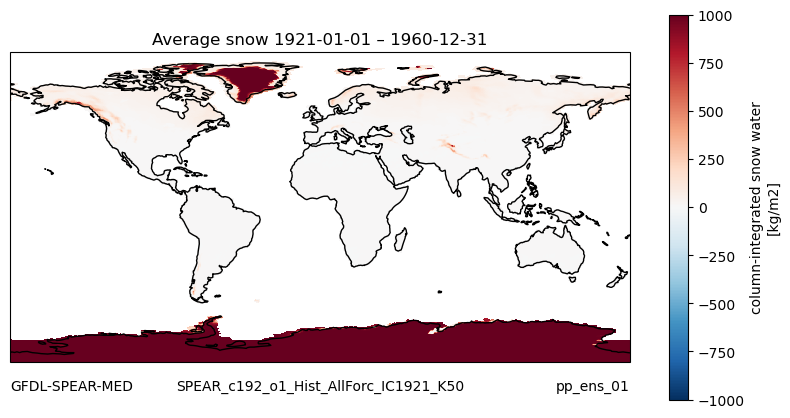

In [47]:
f = ensPlot._make_plot(subcatalog)

In [48]:
f.savefig('/work/a3r/test.png')

shape: (9, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ experimen ┆ frequency ┆ realm     ┆ member_id ┆ … ┆ chunk_fre ┆ cell_meth ┆ standard_ ┆ path     │
│ t_id      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ q         ┆ ods       ┆ name      ┆ ---      │
│ ---       ┆ str       ┆ str       ┆ str       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str      │
│ str       ┆           ┆           ┆           ┆   ┆ str       ┆ str       ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ SPEAR_c19 ┆ day       ┆ atmos_dai ┆ pp_ens_21 ┆ … ┆ 10yr      ┆ ts        ┆ absolute_ ┆ /data/2/ │
│ 2_o1_Scen ┆           ┆ ly        ┆           ┆   ┆           ┆           ┆ value_of_ ┆ GFDL-LAR │
│ _SSP585_I ┆           ┆           ┆           ┆   ┆           ┆           ┆ wind_at_1 ┆ GE-ENSEM │
│ C20…      ┆           ┆           ┆           ┆   ┆           ┆           

/tmp/ipykernel_3405891/3891405600.py:35: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


here


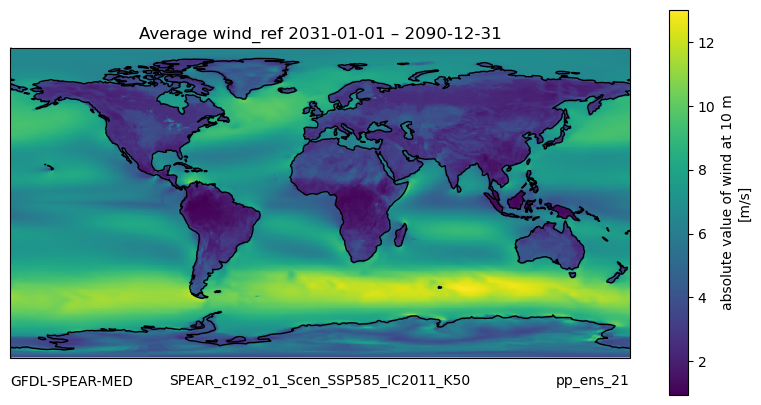

In [52]:
ensPlot.gen_plots()

In [44]:
ds = xr.open_mfdataset(
            subcatalog['path'],
            parallel=True,
            chunks='auto',
            engine='netcdf4'
        )[subcatalog['variable_id'][0]]

/tmp/ipykernel_3405891/2831751212.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [45]:
dask.compute(ds.min())

(<xarray.DataArray 'snow' ()> Size: 4B
 array(-0.21055561, dtype=float32)
 Attributes:
     long_name:      column-integrated snow water
     units:          kg/m2
     cell_methods:   area: mean time: mean
     cell_measures:  area: land_area
     time_avg_info:  average_T1,average_T2,average_DT
     interp_method:  conserve_order1,)